In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import utils

images, names = utils.load_images_from_path("../data/undistorted/")

Image and restored image (should be the same):


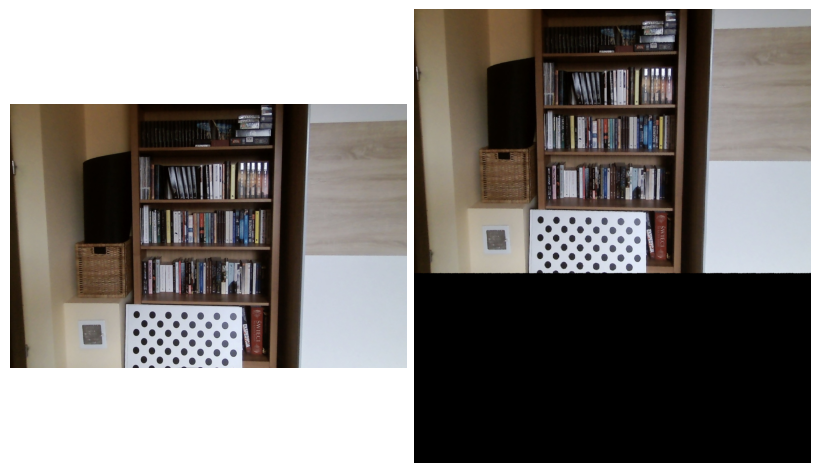

Transformed image:


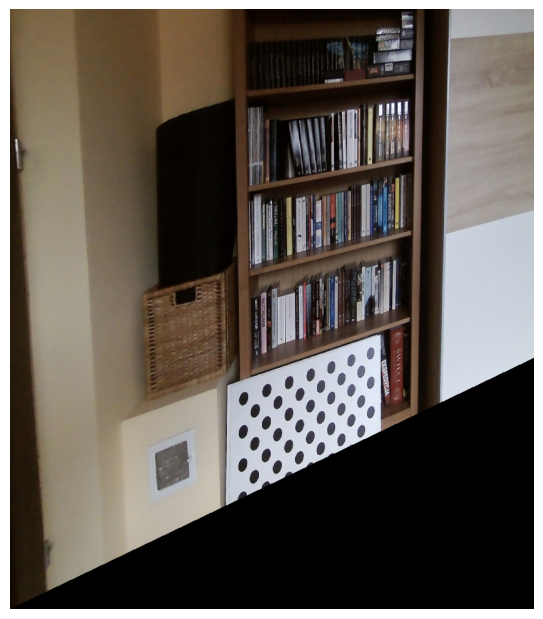

In [3]:
import numpy as np

from projective_transformation import project_transform

H = np.array([[1, 0, 0], [0, 1, 0], [0.0005, 0, 1]])

H_inv = np.linalg.inv(H) / H[2, 2]

image_transformed = project_transform(images[0], H)
image_restored = project_transform(image_transformed, H_inv)

utils.save_image(image_restored, "../data/plots/image_restored.png")
utils.save_image(image_transformed, "../data/plots/image_transformed.png")

print("Image and restored image (should be the same):")
utils.plot_two_imgs(images[0], image_restored)
print("Transformed image:")
utils.plot_img(image_transformed)

### Test the quality of found projective transformations

In [4]:
from tqdm import tqdm
from projective_transformation import transformation_test

good = True
print("Testing projective transformation...")
for _ in tqdm(range(10)):
    if not transformation_test():
        good = False
        break
if good:
    print("All tests passed!")

Testing projective transformation...


100%|██████████| 10/10 [00:00<00:00, 1578.29it/s]

All tests passed!
